In [2]:
import numpy as np
import os
import seaborn as sb
import pingouin as pg
import PcmPy as pcm
import matplotlib.pyplot as plt
import pandas as pd
from SensoriMotorPrediction.vis import plot_rdm
import SensoriMotorPrediction.globals as gl

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=0.218, pval=0.415
PMd: tval=1.579, pval=0.069
PMv: tval=0.746, pval=0.234
M1: tval=4.572, pval=0.000
S1: tval=2.804, pval=0.007
SPLa: tval=2.546, pval=0.012
SPLp: tval=2.191, pval=0.024


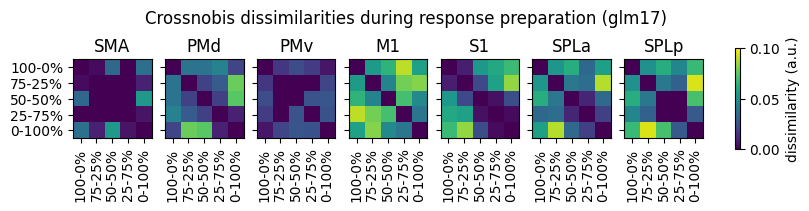

In [3]:
glm = 17
rois = gl.rois['ROI']
H = 'L'
vmin, vmax = 0, .1

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join('data', 'representation', f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, gl.conditions[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

    roi      corr          T         p-val
0    M1  0.411456   4.402246  3.573492e-04
1   PMd  0.523861   5.325125  6.888356e-05
2   PMv  0.427239   4.685895  2.129670e-04
3    S1  0.641085   8.705857  4.378491e-07
4   SMA  0.379069   4.088139  6.406556e-04
5  SPLa  0.378529   4.482359  3.084498e-04
6  SPLp  0.651023  11.723889  1.380724e-08


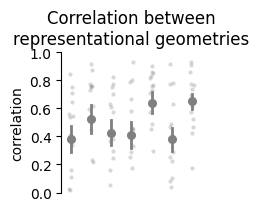

In [4]:
mask = np.tri(5, k=-1, dtype=bool)
corr_dict = {'corr': [], 'roi': [], 'sn': []}
glm1, glm2 = 12, 17
for r, roi in enumerate(rois):
    G16 = np.load(os.path.join('data', 'representation', f'G_obs.plan.glm{glm1}.{H}.{roi}.npy'))
    G17 = np.load(os.path.join('data', 'representation', f'G_obs.plan.glm{glm2}.{H}.{roi}.npy'))
    N = G16.shape[0]
    D = np.r_[pcm.G_to_dist(G16)[:, mask], pcm.G_to_dist(G17)[:, mask]]
    corr = np.diag(np.corrcoef(D)[:N, N:])
    corr_dict['corr'].extend(corr)
    corr_dict['roi'].extend([roi] * corr.size)
    corr_dict['sn'].extend(np.arange(N))

corr_df = pd.DataFrame(corr_dict)

fig, ax = plt.subplots(figsize=(2, 2), constrained_layout=True)
sb.pointplot(ax=ax, data=corr_df, x='roi', y='corr', errorbar='se', lw=2, ls='none', color='grey')
sb.stripplot(ax=ax, data=corr_df, x='roi', y='corr',  size=3, alpha=.3, color='grey')
ax.set_ylim((0, 1))
ax.spines[['top', 'bottom', 'right']].set_visible(False)
ax.set_xticks([])
ax.set_ylabel('correlation')
ax.set_xlabel(None)
ax.set_title(f'Correlation between\nrepresentational geometries')
ttest = corr_df.groupby('roi')['corr'].apply(lambda x: pg.ttest(x, 0, alternative='greater'))
ttest = ttest.reset_index(level=1, drop=True).reset_index()
ttest['corr'] = ttest['roi'].map(corr_df.groupby('roi')['corr'].mean())
print(ttest[['roi', 'corr', 'T', 'p-val']])

fig.savefig('figures/correlation.12vs17.pdf')

plt.show()